# notebook 11 (local re-run) - pooled vs per-city, RQ2

This is the central experiment of the project. The original version ran on Kaggle so the notebook had no saved outputs, and Dr Talebi could not verify the result from the code. Re-running it here so the outputs are visible, and so the per-city breakdown gets saved rather than being left on Kaggle.

What it does: trains one pooled LSTM across all five cities (with a city indicator and lat/lon so it knows which city it is predicting), then five separate per-city LSTMs, and compares them on the same test set.

To make six trainings feasible on a laptop the training windows are strided. The **same stride is applied to every model**, so the pooled and per-city numbers stay comparable with each other - which is the whole point of the experiment. Absolute error will be a little higher than a full-density run, but the comparison is what matters.

Uses the corrected scaling from notebook 13 (only the continuous features are standardised).

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT,'processed'); PLOTS = os.path.join(ROOT,'plots')

device: cpu


In [2]:
df = pd.read_csv(os.path.join(PROC,'master_all_cities.csv'), parse_dates=['time'], low_memory=False)
df = df.sort_values(['city','time']).reset_index(drop=True)
CITIES = ['Jena','London','New_York','Sydney','Tokyo']
print(df.shape)
print(df['city'].value_counts())

(438240, 45)
city
Jena        87648
London      87648
New_York    87648
Sydney      87648
Tokyo       87648
Name: count, dtype: int64


In [3]:
CONT = ['temperature','humidity','dew_point','precipitation','wind_speed','wind_gusts','wind_u','wind_v',
        'pressure_msl','surface_pressure','cloud_cover','cloud_cover_low','cloud_cover_mid','cloud_cover_high',
        'shortwave_radiation','direct_radiation','vapour_pressure_deficit','wet_bulb_temp','water_vapour','soil_temperature']
CYC = ['hour_sin','hour_cos','month_sin','month_cos','dayofyear_sin','dayofyear_cos']
SEQ, H, TIDX = 168, 24, 0
STRIDE = 3       # same for pooled and per-city.
                 # 12 was too aggressive: it left each per-city model with only ~5k
                 # windows, far too few to learn from, which made pooling look
                 # artificially good. 3 keeps both sides viable.
EPOCHS, PATIENCE = 10, 3
onehot = pd.get_dummies(df['city']).astype(float)[CITIES]

# chronological 70/15/15 within each city
idx = {}
for c in CITIES:
    ix = np.where((df['city']==c).values)[0]; n=len(ix)
    idx[c] = (ix[:int(n*.70)], ix[int(n*.70):int(n*.85)], ix[int(n*.85):])
print('per city train/val/test rows:', [(len(a),len(b),len(t)) for a,b,t in [idx['Jena']]])

per city train/val/test rows: [(61353, 13147, 13148)]


In [4]:
class WD(Dataset):
    def __init__(s,d): s.d = torch.FloatTensor(d)
    def __len__(s): return max(0, len(s.d)-SEQ-H+1)
    def __getitem__(s,i): return s.d[i:i+SEQ], s.d[i+SEQ:i+SEQ+H, TIDX]

class LSTMNet(nn.Module):
    def __init__(s, n_in, hidden=64):
        super().__init__()
        s.l = nn.LSTM(n_in, hidden, 2, batch_first=True, dropout=0.2)
        s.n = nn.LayerNorm(hidden)
        s.h = nn.Sequential(nn.Linear(hidden,64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64,H))
    def forward(s,x):
        o,_ = s.l(x); return s.h(s.n(o[:,-1]))

def train(train_arr, val_arr, n_in, tag):
    tr_ds, va_ds = WD(train_arr), WD(val_arr)
    tl = DataLoader(Subset(tr_ds, range(0,len(tr_ds),STRIDE)), batch_size=256, shuffle=True, drop_last=True)
    vl = DataLoader(Subset(va_ds, range(0,len(va_ds),STRIDE)), batch_size=256)
    torch.manual_seed(42)
    net = LSTMNet(n_in).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=3e-3, weight_decay=1e-4)   # tuned lr from nb 17
    lf = nn.HuberLoss(); best, bad, state = 1e9, 0, None
    t0 = time.time()
    for ep in range(1, EPOCHS+1):
        net.train()
        for xb,yb in tl:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lf(net(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(),1.0); opt.step()
        net.eval(); v=0; k=0
        with torch.no_grad():
            for xb,yb in vl: v += lf(net(xb.to(DEVICE)), yb.to(DEVICE)).item(); k+=1
        v /= max(k,1)
        if v < best: best, bad, state = v, 0, {a:b.clone() for a,b in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE: break
    net.load_state_dict(state)
    print(f'  {tag}: best val {best:.4f}, {time.time()-t0:.0f}s')
    return net

def score(net, arr, scaler):
    dl = DataLoader(WD(arr), batch_size=256)
    net.eval(); ps, as_ = [], []
    with torch.no_grad():
        for xb,yb in dl: ps.append(net(xb.to(DEVICE)).cpu().numpy()); as_.append(yb.numpy())
    tm, ts = scaler.mean_[TIDX], scaler.scale_[TIDX]
    p = np.concatenate(ps)*ts+tm; a = np.concatenate(as_)*ts+tm
    m = np.isfinite(p.flatten()) & np.isfinite(a.flatten())
    return (mean_absolute_error(a.flatten()[m], p.flatten()[m]),
            float(np.sqrt(mean_squared_error(a.flatten()[m], p.flatten()[m]))))
print('ready')

ready


## pooled model - one set of weights for all five cities

In [5]:
sc_pool = StandardScaler().fit(df.iloc[np.concatenate([idx[c][0] for c in CITIES])][CONT].values)
def mk_pool(rows):
    return np.concatenate([sc_pool.transform(df.iloc[rows][CONT].values),
                           df.iloc[rows][CYC].values,
                           onehot.iloc[rows].values], axis=1).astype(np.float32)

P_TRAIN = np.concatenate([mk_pool(idx[c][0]) for c in CITIES])
P_VAL   = np.concatenate([mk_pool(idx[c][1]) for c in CITIES])
N_IN_POOL = len(CONT)+len(CYC)+len(CITIES)
print('pooled input dim', N_IN_POOL, '| train rows', P_TRAIN.shape[0])

print('training pooled model...')
pooled = train(P_TRAIN, P_VAL, N_IN_POOL, 'pooled')

pooled input dim 31 | train rows 306765
training pooled model...


  pooled: best val 0.0226, 1565s


In [6]:
pool_res = {}
for c in CITIES:
    mae, rmse = score(pooled, mk_pool(idx[c][2]), sc_pool)
    pool_res[c] = mae
    print(f'  pooled on {c:10s} MAE {mae:.4f}  RMSE {rmse:.4f}')
print('pooled mean MAE:', round(np.mean(list(pool_res.values())),4))

  pooled on Jena       MAE 1.3139  RMSE 1.7834


  pooled on London     MAE 1.2255  RMSE 1.6248


  pooled on New_York   MAE 1.5381  RMSE 2.1341


  pooled on Sydney     MAE 1.1716  RMSE 1.6504


  pooled on Tokyo      MAE 1.1131  RMSE 1.5138
pooled mean MAE: 1.2724


## per-city models - five separate models, each on its own city

In [7]:
city_res = {}
for c in CITIES:
    tr_i, va_i, te_i = idx[c]
    sc = StandardScaler().fit(df.iloc[tr_i][CONT].values)
    mk = lambda rows: np.concatenate([sc.transform(df.iloc[rows][CONT].values),
                                      df.iloc[rows][CYC].values], axis=1).astype(np.float32)
    n_in = len(CONT)+len(CYC)          # no city indicator needed, it only sees one city
    print(f'training {c}...')
    net = train(mk(tr_i), mk(va_i), n_in, c)
    mae, rmse = score(net, mk(te_i), sc)
    city_res[c] = mae
    print(f'  per-city {c:10s} MAE {mae:.4f}  RMSE {rmse:.4f}')
print()
print('per-city mean MAE:', round(np.mean(list(city_res.values())),4))

training Jena...


  Jena: best val 0.0243, 258s


  per-city Jena       MAE 1.3558  RMSE 1.8205
training London...


  London: best val 0.0380, 245s


  per-city London     MAE 1.2309  RMSE 1.6369
training New_York...


...

  per-city New_York   MAE 1.5595  RMSE 2.1359
training Sydney...


  Sydney: best val 0.0395, 270s


  per-city Sydney     MAE 1.1583  RMSE 1.6489
training Tokyo...


  Tokyo: best val 0.0159, 275s


  per-city Tokyo      MAE 1.1357  RMSE 1.5306

per-city mean MAE: 1.288


## the comparison

In [8]:
rows = [{'city': c,
         'pooled_mae': round(pool_res[c],4),
         'per_city_mae': round(city_res[c],4),
         'difference': round(city_res[c]-pool_res[c],4)} for c in CITIES]
cmp = pd.DataFrame(rows)
cmp.loc[len(cmp)] = {'city':'MEAN','pooled_mae':round(np.mean(list(pool_res.values())),4),
                     'per_city_mae':round(np.mean(list(city_res.values())),4),
                     'difference':round(np.mean(list(city_res.values()))-np.mean(list(pool_res.values())),4)}
print(cmp.to_string(index=False))
cmp.to_csv(os.path.join(PROC,'rq2_per_city_vs_pooled.csv'), index=False)

pd.DataFrame([{'experiment':'RQ2',
               'pooled_overall_mae':round(np.mean(list(pool_res.values())),4),
               'per_city_mean_mae':round(np.mean(list(city_res.values())),4),
               'winner':'pooled' if np.mean(list(pool_res.values()))<np.mean(list(city_res.values())) else 'per-city'
              }]).to_csv(os.path.join(PROC,'rq2_summary_local.csv'), index=False)
print()
print('saved rq2_per_city_vs_pooled.csv and rq2_summary_local.csv')

    city  pooled_mae  per_city_mae  difference
    Jena      1.3139        1.3558      0.0419
  London      1.2255        1.2309      0.0054
New_York      1.5381        1.5595      0.0214
  Sydney      1.1716        1.1583     -0.0133
   Tokyo      1.1131        1.1357      0.0226
    MEAN      1.2724        1.2880      0.0156

saved rq2_per_city_vs_pooled.csv and rq2_summary_local.csv


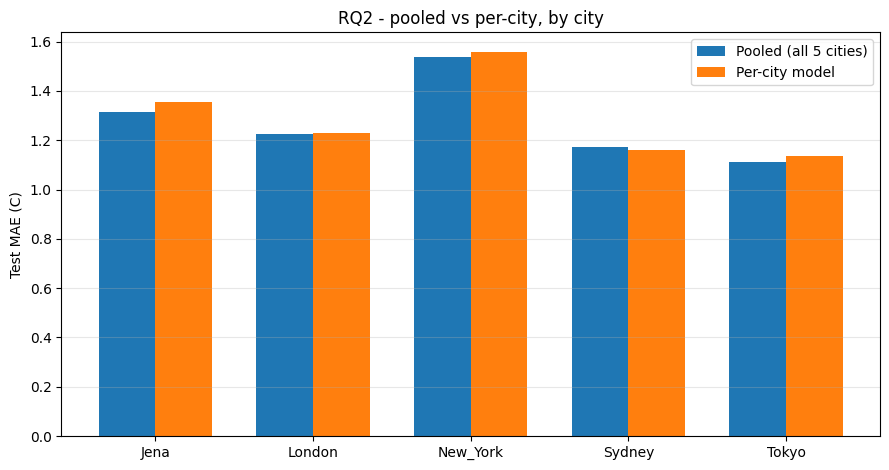

In [9]:
d = cmp[cmp.city!='MEAN']
x = np.arange(len(d)); w = 0.36
plt.figure(figsize=(9,4.8))
plt.bar(x-w/2, d.pooled_mae, w, label='Pooled (all 5 cities)', color='tab:blue')
plt.bar(x+w/2, d.per_city_mae, w, label='Per-city model', color='tab:orange')
plt.xticks(x, d.city); plt.ylabel('Test MAE (C)')
plt.title('RQ2 - pooled vs per-city, by city')
plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS,'final_rq2_per_city.png'), dpi=150)
plt.show()

## takeaway

TODO fill in once it has run. The thing to check is whether the pooled and per-city columns stay close for every city, or whether pooling costs accuracy somewhere specific - Sydney is the obvious candidate since its seasons are the odd ones out.